# 02. Exploratory Data Analysis

Univariate and bivariate exploration of the cleaned dataset, including the derived analytical features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

from src.data_cleaning import load_raw_data, clean_data
from src.segmentation import add_all_features

clean, _ = clean_data(load_raw_data())
df = add_all_features(clean)
print(df.shape)

(7043, 25)


In [2]:
# Numeric summary
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,total_services
count,7043.00,7043.00,7043.0,7043.00
mean,32.37,64.76,2279.73,4.15
std,24.56,30.09,2266.79,2.31
min,0.00,18.25,0.0,1.00
25%,9.00,35.50,398.55,2.00
50%,29.00,70.35,1394.55,4.00
75%,55.00,89.85,3786.6,6.00
max,72.00,118.75,8684.8,9.00


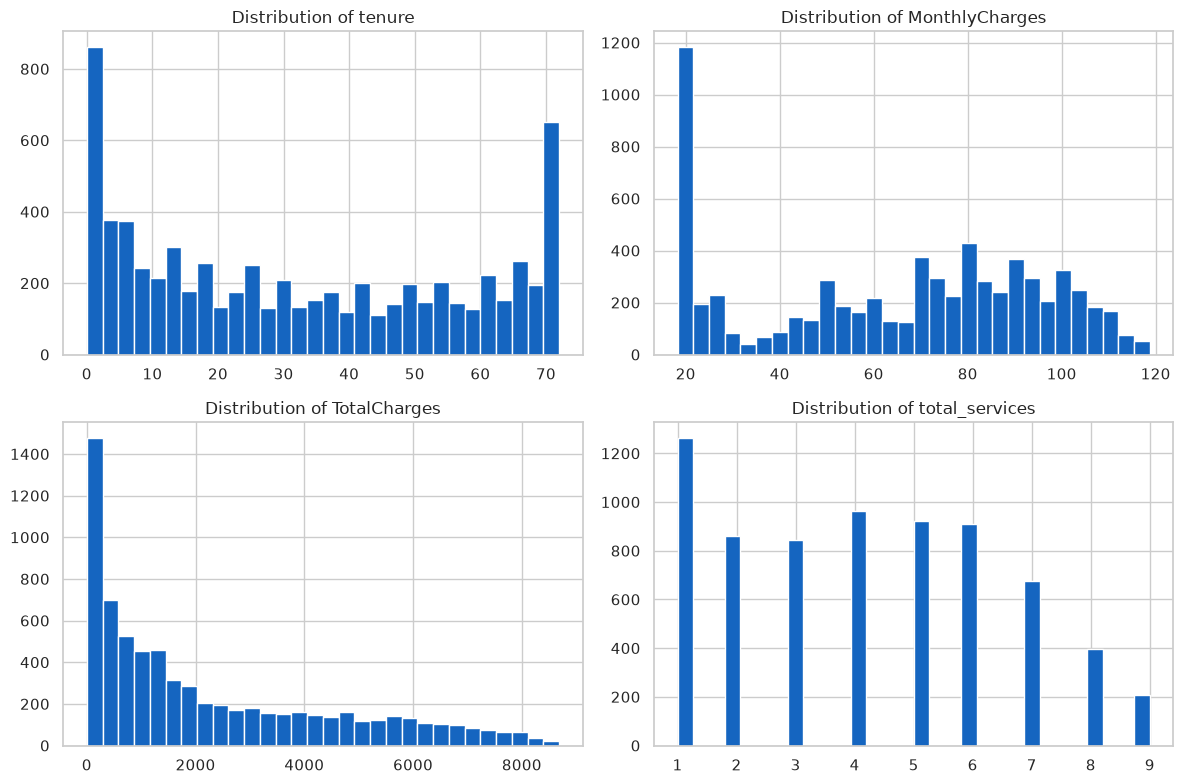

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']):
    ax.hist(df[col], bins=30, color='#1565c0', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [4]:
# Categorical value counts
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract',
            'InternetService', 'PaymentMethod', 'PaperlessBilling']:
    print(col)
    print(df[col].value_counts().to_string())
    print()

gender
gender
Male      3555
Female    3488

SeniorCitizen
SeniorCitizen
No     5901
Yes    1142

Partner
Partner
No     3641
Yes    3402

Dependents
Dependents
No     4933
Yes    2110

Contract
Contract
Month-to-month    3875
Two year          1695
One year          1473

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526

PaymentMethod
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522

PaperlessBilling
PaperlessBilling
Yes    4171
No     2872



In [5]:
# Churn balance
df['Churn'].value_counts(normalize=True).round(4)

Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: Float64

In [6]:
# Tenure group composition
df['tenure_group'].value_counts().sort_index().to_frame('customers')

,customers
tenure_group,
0-6,1481
13-24,1024
25-36,832
37-48,762
49-60,832
61+,1407
7-12,705


## Interpretation

- Tenure is right-skewed with a large early-tenure cluster; many customers are new.
- Monthly charges range ~$18-$119 with a bimodal look (basic phone-only plans vs. full fiber bundles).
- 26.5% of customers churned, so the dataset is reasonably balanced for an observational comparison.